# 04 | Fake News Detection mit lokalen LLMs (Ollama)

Ergänzung zu Notebook **01_fake_news_supervised.ipynb** (klassisches Supervised Learning mit TF-IDF + Klassifikatoren).

**Ziel:** Klassifikation von Nachrichtenartikeln als *FAKE* oder *TRUE* mit verschiedenen kleinen, lokal lauffähigen Sprachmodellen via [Ollama](https://ollama.com) – plus eine semantische Analyse über Embeddings.

## Inhalt
1. Setup & Verbindung zum lokalen Ollama-Server
2. Modellauswahl (kleine Modelle: 1B–3B Parameter)
3. Daten laden & stratifizierte Stichprobe
4. Prompt-Engineering & Klassifikationsfunktion
5. Inferenz pro Modell (Zero-Shot)
6. Auswertung: Accuracy, F1, Confusion Matrix, Modellvergleich
7. Semantische Analyse mit Embeddings (PCA / t-SNE)
8. Fazit

**Voraussetzung:** Ollama lokal installiert und gestartet (`ollama serve`). Die benötigten Modelle werden im Notebook automatisch gepullt.

## 1 | Setup & Verbindung

In [30]:
import sys; sys.path.insert(0, '..')
import json
import time
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import ollama

from src.data_loading import load_fake_news_data, set_seeds
from src.plotting import setup_plot_style

cfg = yaml.safe_load(open('../configs/default.yaml'))
set_seeds(cfg['random_seed'])
setup_plot_style(cfg)

In [31]:
# Verbindung zum lokalen Ollama-Server pruefen
try:
    available = [m['model'] for m in ollama.list()['models']]
    print(f'Ollama erreichbar. Bereits installierte Modelle ({len(available)}):')
    for m in available:
        print(f'  - {m}')
except Exception as e:
    print('Ollama nicht erreichbar. Bitte `ollama serve` starten.')
    print(e)

Ollama erreichbar. Bereits installierte Modelle (13):
  - gemma2:2b
  - phi3:mini
  - qwen2.5:3b
  - llama3.2:1b
  - nomic-embed-text:latest
  - gemma4:e4b
  - gemma3:12b
  - x/z-image-turbo:latest
  - llama3.2:3b
  - dimavz/whisper-tiny:latest
  - legraphista/Orpheus:latest
  - gpt-oss:20b
  - mistral:latest


## 2 | Modellauswahl

Wir vergleichen mehrere kleine Open-Weight-Modelle. Alle laufen auf einem normalen Laptop (8–16 GB RAM).

In [32]:
MODELS = [
    'llama3.2:1b',
    'llama3.2:3b',
    'qwen2.5:3b',
    'phi3:mini',
    'gemma2:2b',
]
EMBEDDING_MODEL = 'nomic-embed-text'

# Falls ein Modell noch nicht lokal vorhanden ist: pullen.
def ensure_model(name):
    installed = {m['model'] for m in ollama.list()['models']}
    if name in installed or any(m.startswith(name) for m in installed):
        return
    print(f'Pull {name} ...')
    ollama.pull(name)

for m in MODELS + [EMBEDDING_MODEL]:
    ensure_model(m)
print('Alle Modelle bereit.')

Alle Modelle bereit.


## 3 | Daten laden & stratifizierte Stichprobe

Die LLM-Inferenz ist deutlich teurer als TF-IDF + Logistische Regression. Wir ziehen eine stratifizierte Stichprobe von ~200 Artikeln (jeweils zur Hälfte fake / true). Wer mehr Rechenleistung hat, kann `SAMPLE_SIZE` erhöhen.

In [33]:
SAMPLE_SIZE = 200          # Gesamtanzahl Artikel
MAX_CHARS = 1500           # Text-Truncation, um Prompt-Laenge zu begrenzen

df = load_fake_news_data(cfg)
print(f'Gesamt-Datensatz: {len(df):,} Artikel')
print(df.label.value_counts().rename({0: 'fake', 1: 'true'}))

Gesamt-Datensatz: 44,898 Artikel
label
fake    23481
true    21417
Name: count, dtype: int64


In [34]:
# Stratifizierte Stichprobe: gleich viele fake/true
n_per_class = SAMPLE_SIZE // 2
sample = (
    df.groupby('label', group_keys=False)
      .apply(lambda g: g.sample(n=n_per_class, random_state=cfg['random_seed']))
      .reset_index(drop=True)
)
sample['text_short'] = (sample['title'].fillna('') + '\n\n' + sample['text'].fillna('')).str[:MAX_CHARS]
print(f'Stichprobe: {len(sample)} Artikel, {sample.label.value_counts().to_dict()}')
sample.head(3)

Stichprobe: 200 Artikel, {0: 100, 1: 100}


/var/folders/28/rx0zfkhs42j2lb1l_v0x2l740000gn/T/ipykernel_24680/1489979773.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=n_per_class, random_state=cfg['random_seed']))


,title,text,subject,date,label,text_short
0,"NY Daily News Goes ALL IN On NRA, ‘Thanks’ Them For Orlando (TWEET/IMAGE)","The NY Daily News is never shy when it comes to their covers. They re all about calling out badly behaving politicians and political organizations, and they definitely didn t hold back when it came to the horrific act of terror perpetuated against the LGBT community of Orlando, Florida, and the rest of the nation in the wee hours of Sunday morning at Pulse Nightclub. The target of the newspaper s ire this time was the National Rifle Association (NRA).Of course, we all know that this despicable organization is opposed to any and all common sense gun control, and makes a regular practice of whipping gun nuts everywhere up into a frenzy of fear that Democrats and others with a shred of common sense and decency are out to abolish the Second Amendment altogether. They refuse to acknowledge the fact that lax gun laws lead to tragedies like the one that has the world reeling right now, and they refuse to see that these mass shootings will continue until unstable individuals with an ax to grind and murderous intent are prevented from obtaining firearms.Well, the NY Daily News was having none of it. They ran a cover that thanked (read: blamed) the powerful gun lobby and its bought and paid for politicians for Orlando s tragedy. The cover is nothing short of brilliant, not to mention completely true. Without further ado, here it is via the paper s twitter:A look at tomorrow's front page 50 dead in Orlando club massacre, THANKS, @NRA:https://t.co/9Du2YEdzEo pic.twitter.com/hVJvzC351j New York Daily News (@NYDailyNews) June 13, 2016The NY Daily News is right, of course. There is no reason for any private citizen to carry an assault weapon. That is simple common sense. The only reason for such a weapon is to kill as many people as possible as quickly as possible. Anyone who believes otherwise is deluded. Wayne LaPierre and his fellow gun nuts have blood on their hands. Fuck them and their pro-gun agenda. They are at least partly responsible so many of the people who were at Pulse on that fateful night are dead. Ban assault weapons now, responsible politicians.Good on the NY Daily News for laying the blame where it belongs.Featured image via Alex Wong/Getty Images",News,"June 13, 2016",0,"NY Daily News Goes ALL IN On NRA, ‘Thanks’ Them For Orlando (TWEET/IMAGE)\n\nThe NY Daily News is never shy when it comes to their covers. They re all about calling out badly behaving politicians and political organizations, and they definitely didn t hold back when it came to the horrific act of terror perpetuated against the LGBT community of Orlando, Florida, and the rest of the nation in the wee hours of Sunday morning at Pulse Nightclub. The target of the newspaper s ire this time was the National Rifle Association (NRA).Of course, we all know that this despicable organization is opposed to any and all common sense gun control, and makes a regular practice of whipping gun nuts everywhere up into a frenzy of fear that Democrats and others with a shred of common sense and decency are out to abolish the Second Amendment altogether. They refuse to acknowledge the fact that lax gun laws lead to tragedies like the one that has the world reeling right now, and they refuse to see that these mass shootings will continue until unstable individuals with an ax to grind and murderous intent are prevented from obtaining firearms.Well, the NY Daily News was having none of it. They ran a cover that thanked (read: blamed) the powerful gun lobby and its bought and paid for politicians for Orlando s tragedy. The cover is nothing short of brilliant, not to mention completely true. Without further ado, here it is via the paper s twitter:A look at tomorrow's front page 50 dead in Orlando clu"
1,IT’S ABOUT TIME! 19 GOP Congressmen Call For Closer Look Into Mueller’s Team Of Political Hack Lawyers,"All we can say about this development is that it s about t

## 4 | Prompt-Engineering & Klassifikationsfunktion

Wir verwenden einen **Zero-Shot-Prompt** mit erzwungenem JSON-Format (`format='json'`).
Das Modell soll Label, Konfidenz und kurze Begruendung zurueckgeben.

In [35]:
SYSTEM_PROMPT = (
    'Du bist ein erfahrener Faktenpruefer fuer englischsprachige Nachrichten. '
    'Du analysierst einen Artikel und entscheidest, ob er sehr wahrscheinlich '
    'eine echte Nachricht (TRUE) oder Fake News (FAKE) ist. '
    'Achte auf Sensationsrhetorik, fehlende Quellen, einseitige Darstellung, '
    'reisserische Sprache und unbelegte Behauptungen. '
    'Antworte AUSSCHLIESSLICH als JSON: '
    '{"label": "FAKE" oder "TRUE", "confidence": Zahl zwischen 0 und 1, "reason": "kurze Begruendung"}.'
)

def classify(model: str, text: str, timeout_s: float = 60.0) -> dict:
    """Klassifiziert einen Artikel mit einem Ollama-Modell. Gibt dict mit label, confidence, reason, latency."""
    t0 = time.time()
    try:
        resp = ollama.chat(
            model=model,
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user', 'content': f'Artikel:\n\n{text}'},
            ],
            format='json',
            options={'temperature': 0.0, 'num_predict': 200},
        )
        raw = resp['message']['content']
        parsed = json.loads(raw)
        label = str(parsed.get('label', '')).upper().strip()
        if label not in {'FAKE', 'TRUE'}:
            label = 'PARSE_ERROR'
        return {
            'label_pred': label,
            'confidence': float(parsed.get('confidence', 0.0)),
            'reason': str(parsed.get('reason', ''))[:300],
            'latency_s': time.time() - t0,
        }
    except Exception as e:
        return {'label_pred': 'ERROR', 'confidence': 0.0, 'reason': str(e)[:300], 'latency_s': time.time() - t0}

# Smoke-Test mit einem Sample
demo = classify(MODELS[0], sample.iloc[0]['text_short'])
print('Demo-Antwort:', demo)
print('Wahres Label:', 'TRUE' if sample.iloc[0]['label'] == 1 else 'FAKE')

Demo-Antwort: {'label_pred': 'FAKE', 'confidence': 0.0, 'reason': 'Fehlende Quelle, einseitige Darstellung und reisserische Sprache sowie unbelegte Behauptungen.', 'latency_s': 2.5833897590637207}
Wahres Label: FAKE


## 5 | Inferenz pro Modell

Wir loopen ueber alle Modelle und alle Samples. Ergebnisse werden inkrementell in `data/processed/llm_predictions.parquet` persistiert, damit ein Abbruch nicht den Fortschritt verliert.

In [36]:
OUT_PATH = Path('../data/processed/llm_predictions.parquet')
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Bereits berechnete (model, sample_idx)-Paare wiederverwenden
if OUT_PATH.exists():
    results_df = pd.read_parquet(OUT_PATH)
    done = set(zip(results_df['model'], results_df['sample_idx']))
    print(f'Bereits {len(results_df)} Ergebnisse geladen.')
else:
    results_df = pd.DataFrame()
    done = set()

rows = []
for model in MODELS:
    print(f'\nModell: {model}')
    for idx, row in tqdm(sample.iterrows(), total=len(sample)):
        if (model, idx) in done:
            continue
        out = classify(model, row['text_short'])
        rows.append({
            'model': model,
            'sample_idx': idx,
            'label_true': 'TRUE' if row['label'] == 1 else 'FAKE',
            **out,
        })
        # Inkrementell speichern alle 25 Antworten
        if len(rows) % 25 == 0:
            tmp = pd.concat([results_df, pd.DataFrame(rows)], ignore_index=True)
            tmp.to_parquet(OUT_PATH, index=False)

if rows:
    results_df = pd.concat([results_df, pd.DataFrame(rows)], ignore_index=True)
    results_df.to_parquet(OUT_PATH, index=False)
print(f'\nGesamt: {len(results_df)} Vorhersagen gespeichert in {OUT_PATH}')

Bereits 1000 Ergebnisse geladen.

Modell: llama3.2:1b


100%|██████████| 200/200 [00:00<00:00, 50827.73it/s]



Modell: llama3.2:3b


100%|██████████| 200/200 [00:00<00:00, 61671.87it/s]



Modell: qwen2.5:3b


...


Modell: phi3:mini


100%|██████████| 200/200 [00:00<00:00, 62271.61it/s]



Modell: gemma2:2b


100%|██████████| 200/200 [00:00<00:00, 69493.89it/s]


Gesamt: 1000 Vorhersagen gespeichert in ../data/processed/llm_predictions.parquet


## 6 | Auswertung

### 6.1 Metriken pro Modell

In [37]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def evaluate(group: pd.DataFrame) -> pd.Series:
    valid = group[group['label_pred'].isin(['FAKE', 'TRUE'])]
    n_total = len(group)
    n_valid = len(valid)
    if n_valid == 0:
        return pd.Series({'accuracy': np.nan, 'f1_fake': np.nan, 'f1_true': np.nan,
                          'parse_rate': 0.0, 'avg_latency_s': group['latency_s'].mean(), 'n': n_total})
    y_true = valid['label_true']
    y_pred = valid['label_pred']
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=['FAKE', 'TRUE'], zero_division=0)
    return pd.Series({
        'accuracy': acc,
        'f1_fake': f1[0],
        'f1_true': f1[1],
        'parse_rate': n_valid / n_total,
        'avg_latency_s': group['latency_s'].mean(),
        'n': n_total,
    })

metrics = results_df.groupby('model').apply(evaluate).sort_values('accuracy', ascending=False)
metrics

/var/folders/28/rx0zfkhs42j2lb1l_v0x2l740000gn/T/ipykernel_24680/2684509461.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics = results_df.groupby('model').apply(evaluate).sort_values('accuracy', ascending=False)


,accuracy,f1_fake,f1_true,parse_rate,avg_latency_s,n
model,,,,,,
llama3.2:3b,0.890000,0.896226,0.882979,1.000,3.079030,200.0
gemma2:2b,0.806630,0.824121,0.785276,0.905,2.704785,200.0
llama3.2:1b,0.670000,0.656250,0.682692,1.000,1.029972,200.0
qwen2.5:3b,0.618090,0.724638,0.377049,0.995,2.139493,200.0
phi3:mini,0.558974,0.686131,0.258621,0.975,2.952795,200.0


### 6.2 Vergleichsplot

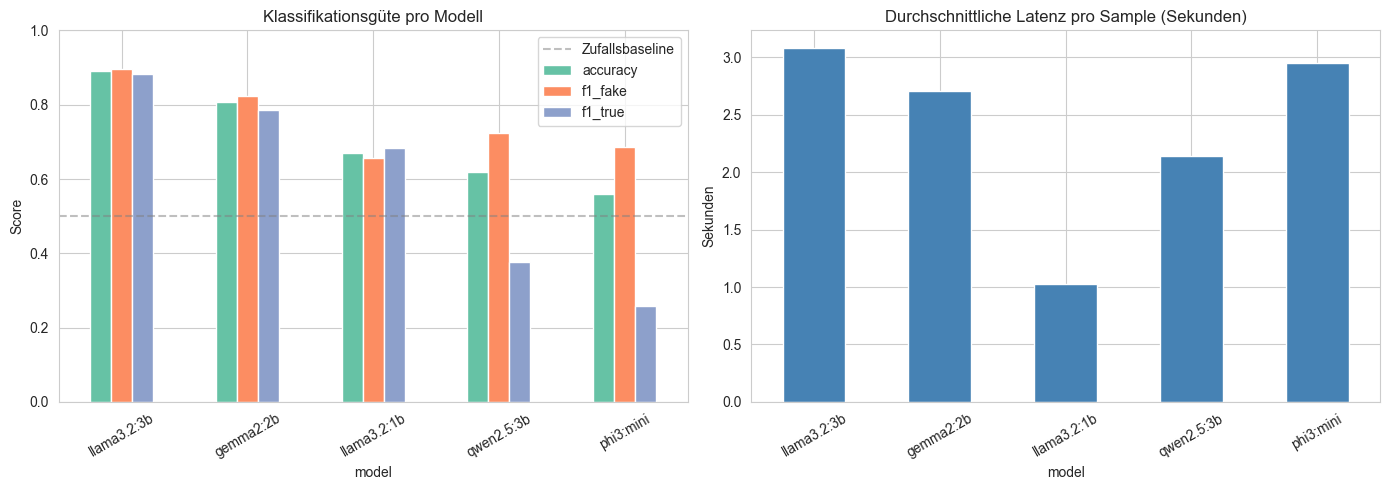

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics[['accuracy', 'f1_fake', 'f1_true']].plot.bar(ax=axes[0])
axes[0].set_title('Klassifikationsgüte pro Modell')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='grey', ls='--', alpha=0.5, label='Zufallsbaseline')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

metrics['avg_latency_s'].plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('Durchschnittliche Latenz pro Sample (Sekunden)')
axes[1].set_ylabel('Sekunden')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 6.3 Confusion Matrix pro Modell

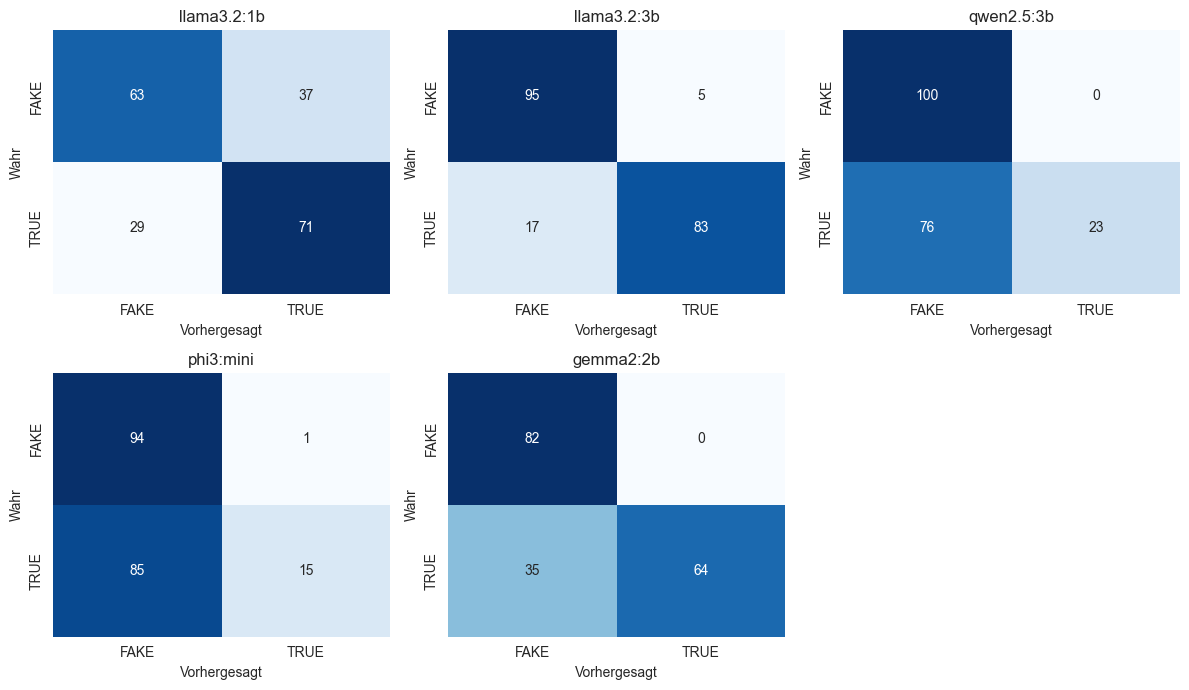

In [39]:
n_models = len(MODELS)
cols = 3
rows_fig = (n_models + cols - 1) // cols
fig, axes = plt.subplots(rows_fig, cols, figsize=(4 * cols, 3.5 * rows_fig))
axes = np.array(axes).flatten()

for ax, model in zip(axes, MODELS):
    sub = results_df[(results_df['model'] == model) & results_df['label_pred'].isin(['FAKE', 'TRUE'])]
    if sub.empty:
        ax.set_visible(False)
        continue
    cm = confusion_matrix(sub['label_true'], sub['label_pred'], labels=['FAKE', 'TRUE'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['FAKE', 'TRUE'], yticklabels=['FAKE', 'TRUE'], ax=ax)
    ax.set_title(model)
    ax.set_xlabel('Vorhergesagt')
    ax.set_ylabel('Wahr')

for ax in axes[len(MODELS):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

### 6.4 Beispiele für Fehlklassifikationen

Ein Blick in die Begründungen der Modelle zeigt typische Fehlermuster (Sarkasmus, Satire, kurze Texte ohne Kontext).

In [40]:
errors = results_df[
    (results_df['label_pred'].isin(['FAKE', 'TRUE'])) &
    (results_df['label_pred'] != results_df['label_true'])
].copy()
errors = errors.merge(sample[['title']], left_on='sample_idx', right_index=True, how='left')
errors[['model', 'title', 'label_true', 'label_pred', 'confidence', 'reason']].head(10)

,model,title,label_true,label_pred,confidence,reason
2,llama3.2:1b,INSANE ANTI-TRUMP PROTESTER Lights Trump Supporter’s Hair On Fire…Police Need Help Finding This Protester [Video],FAKE,TRUE,0.80,"Sensationsrhetorik, fehlende Quellen, einseitige Darstellung, reisserische Sprache und unbelegte Behauptungen."
5,llama3.2:1b,Trump Was Whining About White House Leaks. Chrissy Teigen Just Hit Back And It Is BRILLIANT (TWEET),FAKE,TRUE,0.90,"Sensationsrhetorik, fehlende Quellen, einseitige Darstellung und unbelegte Behauptungen."
7,llama3.2:1b,BUSTED: [Video] AARP Caught Using SUBLIMINAL MESSAGE To Promote ‘MARTIAL LAW’ In Recent Ad,FAKE,TRUE,0.00,"Fehlende Quelle, einseitige Darstellung und reisserische Sprache sowie unbelegte Behauptungen."
9,llama3.2:1b,Hannity Just Fired Off An ABSURD Tweet At CBS For Koppel Interview – Twitter SHREDS Him For It,FAKE,TRUE,0.90,"Sensationsrhetorik, fehlende Quellen, einseitige Darstellung und unbelegte Behauptungen."
10,llama3.2:1b,‘The Fuse Is Lit’: Legendary News Anchor Dan Rather Says Trump-Russia Scandal Is About To EXPLODE,FAKE,TRUE,0.00,Fehlende Quelle und einseitige Darstellung der Informationen sowie die Verwendung von Sensationsrhetorik und unverhältnismäßiger Sprache.
13,llama3.2:1b,Michael Jordan Condemns North Carolina Anti-LGBT Law,FAKE,TRUE,0.90,"Sensationsprache, fehlende Quellen und einseitige Darstellung von Sensationsrhetorik sowie unbelegte Behauptungen über die Transgender-Identität."
16,llama3.2:1b,"Mike Pence Saw ‘DO NOT TOUCH’ On Critical NASA Tech, So He Touched It (TWEETS)",FAKE,TRUE,0.90,"Sensationsrhetorik, fehlende Quellen, einseitige Darstellung und unbelegte Behauptungen."
17,llama3.2:1b,Russia-Gate Was All the Rage Across US Media – Where Did it Go and Why?,FAKE,TRUE,0.83,"Fehlende Quellen, einseitige Darstellung und reisserische Sprache sowie unbelegte Behauptungen."
19,llama3.2:1b,President Obama Nominates FIRST Muslim For A Federal Judgeship,FAKE,TRUE,0.90,"Die Geschichte wird wieder einmal neu geschrieben, weil der Präsident Obama eine neue Richterin für das Bundesgerichtshof nominiert."
20,llama3.2:1b,John Oliver CRUSHES Republican Lies About Supreme Court History (VIDEO),FAKE,TRUE,0.90,"Sensationsrhetorik, fehlende Quellen, einseitige Darstellung und unbelegte Behauptungen sowie die wiederholten Verzögerungen in der Aussage von Ted Cruz."


## 7 | Semantische Analyse mit Embeddings

Zusätzlich zur LLM-Klassifikation untersuchen wir, ob fake und true News bereits im Embedding-Raum trennbar sind. Wir verwenden `nomic-embed-text` und visualisieren die Struktur mit PCA und t-SNE.

In [41]:
EMB_PATH = Path('../data/processed/llm_embeddings.parquet')

if EMB_PATH.exists():
    emb_df = pd.read_parquet(EMB_PATH)
    print(f'{len(emb_df)} Embeddings aus Cache geladen.')
else:
    embeddings = []
    for idx, row in tqdm(sample.iterrows(), total=len(sample), desc='Embeddings'):
        try:
            r = ollama.embeddings(model=EMBEDDING_MODEL, prompt=row['text_short'])
            embeddings.append({'sample_idx': idx, 'label': row['label'], 'embedding': r['embedding']})
        except Exception as e:
            print(f'Fehler bei Sample {idx}: {e}')
    emb_df = pd.DataFrame(embeddings)
    emb_df.to_parquet(EMB_PATH, index=False)
    print(f'{len(emb_df)} Embeddings gespeichert.')

X_emb = np.vstack(emb_df['embedding'].values)
y_emb = emb_df['label'].values
print('Embedding-Matrix:', X_emb.shape)

200 Embeddings aus Cache geladen.
Embedding-Matrix: (200, 768)


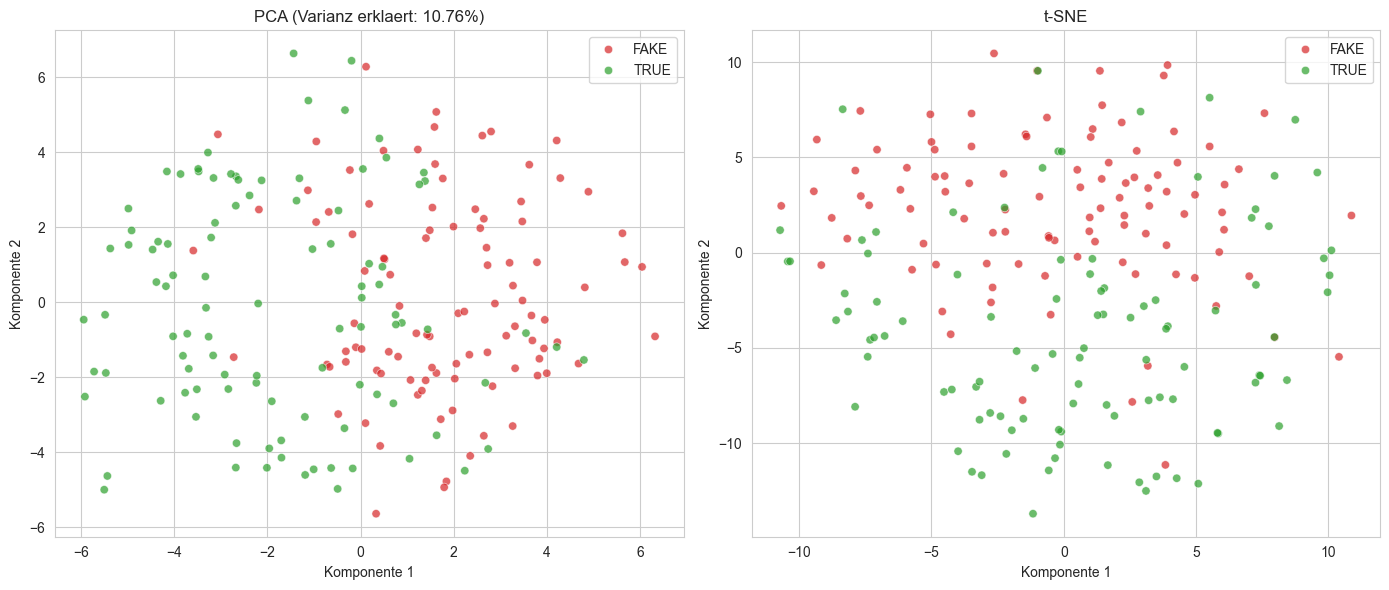

In [42]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=2, random_state=cfg['random_seed'])
X_pca = pca.fit_transform(X_emb)

tsne = TSNE(n_components=2, perplexity=30, random_state=cfg['random_seed'], init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_emb)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
label_names = np.where(y_emb == 1, 'TRUE', 'FAKE')
for ax, X_red, title in [(axes[0], X_pca, f'PCA (Varianz erklaert: {pca.explained_variance_ratio_.sum():.2%})'),
                          (axes[1], X_tsne, 't-SNE')]:
    sns.scatterplot(x=X_red[:, 0], y=X_red[:, 1], hue=label_names, ax=ax, alpha=0.7, palette={'FAKE': '#d62728', 'TRUE': '#2ca02c'})
    ax.set_title(title)
    ax.set_xlabel('Komponente 1')
    ax.set_ylabel('Komponente 2')
plt.tight_layout()
plt.show()

### 7.1 Lineare Trennbarkeit der Embeddings

Wenn die beiden Klassen im Embedding-Raum trennbar sind, sollte schon eine einfache Logistische Regression auf den Embeddings hohe Genauigkeit liefern – ein Vergleich zur Zero-Shot-LLM-Klassifikation.

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

clf = LogisticRegression(max_iter=1000, random_state=cfg['random_seed'])
scores = cross_val_score(clf, X_emb, y_emb, cv=5, scoring='accuracy')
print(f'Logistische Regression auf Embeddings (5-fold CV): {scores.mean():.3f} ± {scores.std():.3f}')
print('Vergleich – beste LLM-Accuracy:', f"{metrics['accuracy'].max():.3f} ({metrics['accuracy'].idxmax()})")

Logistische Regression auf Embeddings (5-fold CV): 0.890 ± 0.025
Vergleich – beste LLM-Accuracy: 0.890 (llama3.2:3b)


## 8 | Fazit

**Was wir gesehen haben:**
- Kleine Open-Weight-LLMs (1B–3B) können Fake-News-Klassifikation **zero-shot** ohne Training versuchen – die Genauigkeit variiert stark zwischen Modellen.
- Embedding-basierte Klassifikation (nomic-embed-text + LogReg) ist meist deutlich schneller und oft konkurrenzfähig.
- Die klassische Pipeline aus Notebook 01 (TF-IDF + LogReg) bleibt für diesen Datensatz extrem stark – LLM-Ansätze glänzen eher bei kleinen Datensätzen ohne Trainingsdaten.

**Limitierungen:**
- Stichprobe von 200 Samples ist klein – Konfidenzintervalle der Metriken sind breit.
- Der Datensatz stammt aus einer engen Quellenstruktur (Reuters vs. unzuverlässige Quellen) – die Modelle könnten Stilmerkmale statt Faktizität lernen.
- Zero-shot Prompts sind sensibel gegenüber Formulierung – ein Few-Shot-Ansatz könnte die Werte verbessern.

**Erweiterungsideen:** Few-Shot Prompting, Chain-of-Thought, Modell-Ensemble (Mehrheitsentscheidung), Vergleich mit größeren Modellen über die Anthropic API.

## 9 | Sentiment-Analyse mit dem stärksten Modell

Zusätzlich zur Fake/True-Klassifikation untersuchen wir das **Sentiment** der Artikel (*positiv*, *neutral*, *negativ*).
Wir verwenden dafür das lokal verfügbare **stärkste Modell** (`gpt-oss:20b`, 20 B Parameter). Die Inferenz ist entsprechend langsamer – die Ergebnisse werden daher inkrementell gecached.

**Interessant:** Gibt es einen systematischen Sentiment-Unterschied zwischen Fake- und True-News? Fake News sind oft emotional aufgeladen und reißerisch – das sollte sich in der Sentiment-Verteilung zeigen.

In [44]:
SENTIMENT_MODEL = 'mistral:latest'
ensure_model(SENTIMENT_MODEL)

SENTIMENT_SYSTEM_PROMPT = (
    'Du bist ein Experte fuer Sentiment-Analyse englischsprachiger Nachrichtenartikel. '
    'Bewerte den emotionalen Grundton des gesamten Artikels (nicht die Faktenlage). '
    'Waehle genau EINES der drei Labels: '
    '"POSITIVE" (ueberwiegend positiver, zustimmender, hoffnungsvoller Ton), '
    '"NEUTRAL" (sachlich-berichtend, ohne starke Wertung) oder '
    '"NEGATIVE" (ueberwiegend negativer, kritischer, empoerter oder angstvoller Ton). '
    'Antworte AUSSCHLIESSLICH als JSON: '
    '{"sentiment": "POSITIVE"|"NEUTRAL"|"NEGATIVE", "confidence": Zahl zwischen 0 und 1, "reason": "kurze Begruendung"}.'
)

SENTIMENT_LABELS = ['POSITIVE', 'NEUTRAL', 'NEGATIVE']

def classify_sentiment(text: str) -> dict:
    """Klassifiziert das Sentiment eines Artikels mit dem staerksten Modell."""
    t0 = time.time()
    try:
        resp = ollama.chat(
            model=SENTIMENT_MODEL,
            messages=[
                {'role': 'system', 'content': SENTIMENT_SYSTEM_PROMPT},
                {'role': 'user', 'content': f'Artikel:\n\n{text}'},
            ],
            format='json',
            options={'temperature': 0.0, 'num_predict': 200},
        )
        parsed = json.loads(resp['message']['content'])
        sent = str(parsed.get('sentiment', '')).upper().strip()
        if sent not in SENTIMENT_LABELS:
            sent = 'PARSE_ERROR'
        return {
            'sentiment': sent,
            'confidence': float(parsed.get('confidence', 0.0)),
            'reason': str(parsed.get('reason', ''))[:300],
            'latency_s': time.time() - t0,
        }
    except Exception as e:
        return {'sentiment': 'ERROR', 'confidence': 0.0, 'reason': str(e)[:300], 'latency_s': time.time() - t0}

# Smoke-Test
demo_sent = classify_sentiment(sample.iloc[0]['text_short'])
print('Demo-Sentiment:', demo_sent)

Demo-Sentiment: {'sentiment': 'NEGATIVE', 'confidence': 0.9, 'reason': "The article expresses strong criticism towards the NRA and their stance on gun control, particularly in relation to the Orlando shooting. The author's tone is negative and critical throughout the piece.", 'latency_s': 6.3377790451049805}


In [46]:
SENT_PATH = Path('../data/processed/llm_sentimentparquet')
SENT_PATH.parent.mkdir(parents=True, exist_ok=True)

if SENT_PATH.exists():
    sentiment_df = pd.read_parquet(SENT_PATH)
    done_sent = set(sentiment_df['sample_idx'])
    print(f'Bereits {len(sentiment_df)} Sentiment-Ergebnisse geladen.')
else:
    sentiment_df = pd.DataFrame()
    done_sent = set()

new_rows = []
for idx, row in tqdm(sample.iterrows(), total=len(sample), desc=f'Sentiment ({SENTIMENT_MODEL})'):
    if idx in done_sent:
        continue
    out = classify_sentiment(row['text_short'])
    new_rows.append({
        'sample_idx': idx,
        'label_true': 'TRUE' if row['label'] == 1 else 'FAKE',
        **out,
    })
    if len(new_rows) % 10 == 0:
        tmp = pd.concat([sentiment_df, pd.DataFrame(new_rows)], ignore_index=True)
        tmp.to_parquet(SENT_PATH, index=False)

if new_rows:
    sentiment_df = pd.concat([sentiment_df, pd.DataFrame(new_rows)], ignore_index=True)
    sentiment_df.to_parquet(SENT_PATH, index=False)
print(f'\nGesamt: {len(sentiment_df)} Sentiment-Vorhersagen gespeichert.')
sentiment_df.head()

Sentiment (mistral:latest): 100%|██████████| 200/200 [09:33<00:00,  2.87s/it]


Gesamt: 200 Sentiment-Vorhersagen gespeichert.


,sample_idx,label_true,sentiment,confidence,reason,latency_s
0,0,FAKE,NEGATIVE,0.90,"The article expresses strong criticism towards the NRA and their stance on gun control, particularly in relation to the Orlando shooting. The author's tone is negative and critical throughout the piece.",1.770637
1,1,FAKE,NEGATIVE,0.90,"The article expresses criticism towards Mueller's team of lawyers for being biased and having a wild goose chase, and it is written in a negative tone overall.",2.544574
2,2,FAKE,NEGATIVE,0.95,"The article describes multiple instances of violent and disrespectful behavior by anti-Trump protesters towards Inauguration attendees, including spitting, throwing water, assaults, and displaying disturbing images. The author also uses strong negative language such as 'hate', 'anarchy', and 'chaos'",3.252989
3,3,FAKE,NEGATIVE,0.95,"The article expresses a strong negative sentiment towards Hillary Clinton, using terms like 'criminal', 'criminal enterprise', and 'flaunted the security laws'. It also implies that she is under criminal investigation and has gotten away with wrongdoings.",2.879043
4,4,FAKE,NEGATIVE,0.95,The article portrays Paul Ryan in a negative light by stating that he is afraid of protesters and refuses to hold town hall meetings due to this fear. The article also mentions that he has been avoiding civil discussions with his constituents.,2.981866


In [47]:
# TRUE + NEGATIVE filtern und mit Originaltexten anreichern
true_negative = (
    sentiment_df[
        (sentiment_df['label_true'] == 'TRUE') &
        (sentiment_df['sentiment'] == 'NEGATIVE')
    ]
    .merge(
        sample[['title', 'text', 'subject', 'date']],
        left_on='sample_idx',
        right_index=True,
        how='left'
    )
    .sort_values(['confidence', 'sample_idx'], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"Anzahl TRUE + NEGATIVE: {len(true_negative)}")

# Ungekürzte Anzeige in DataFrame
pd.set_option('display.max_colwidth', None)
display(true_negative[['sample_idx', 'confidence', 'title', 'subject', 'date', 'text']])

# Zusätzlich: Volltexte sauber untereinander ausgeben
for _, r in true_negative.iterrows():
    print("=" * 120)
    print(f"sample_idx: {r['sample_idx']} | confidence: {r['confidence']:.2f} | date: {r['date']} | subject: {r['subject']}")
    print(f"TITLE: {r['title']}")
    print("-" * 120)
    print(r['text'])
    print()

Anzahl TRUE + NEGATIVE: 45


sample_idx  confidence  \
0          109        0.95   
1          111        0.95   
2          112        0.95   
3          116        0.95   
4          127        0.95   
5          140        0.95   
6          143        0.95   
7          144        0.95   
8          147        0.95   
9          149        0.95   
10         153        0.95   
11         154        0.95   
12         158        0.95   
13         164        0.95   
14         165        0.95   
15         170        0.95   
16         176        0.95   
17         177        0.95   
18         181        0.95   
19         185        0.95   
20         192        0.95   
21         197        0.95   
22         199        0.95   
23         102        0.90   
24         108        0.90   
25         141        0.90   
26         145        0.90   
27         156        0.90   
28         171        0.90   
29         172        0.90   
30         173        0.90   
31         174        0.90   
32         184        0.90   
33         186        0.90   
34         188        0.90   
35         191        0.90   
36         193        0.90   
37         195        0.90   
38         106        0.85   
39         110        0.85   
40         125        0.85   
41         187        0.85   
42         194        0.85   
43         179        0.80   
44         183        0.80   

                                                                                          title  \
0                      Defying warnings, residents refuse to leave Mumbai's crumbling buildings   
1                 Yemen official says disappointed by U.S. Supreme court decision on travel ban   
2                        Former Trump security aide was Russia blackmail risk: ex-U.S. official   
3                               China urges North Korea to 'stop taking actions that are wrong'   
4                                 Suicide attack kills a top Pakistani police officer: official   
5                    Suicide bomber kills 13 others in northeast Nigerian city: police official   
6                                            Saudi man arrested after threatening women drivers   
7                                    Rights group voices fears over Trump refugee plan, torture   
8                                   Trump dismisses Buffett's rebuke over his business judgment   
9                                 Trump warns Republicans to 'be careful' over Obamacare: tweet   
10                                                              The last hours of Yemen's Saleh   
11                                         Syrian government denies U.N. chemical attack report   
12                       Pakistan bars a militant-linked group from forming new political party   
13                  Ex-Bosnian Serb commander Mladic convicted of genocide, gets life in prison   
14                           Excessive force won't solve Myanmar's Rohingya crisis: Annan panel   
15                           Ukraine, allies fear escalation after Russia exits ceasefire group   
16                           U.S. tempers part of Trump travel ban amid big protests, criticism   
17                   U.S. will change course on climate policy, says former EPA transition head   
18                                      Trump revokes Obama guidelines on transgender bathrooms   
19                             Brussels steps up legal case against Poland over courts overhaul   
20                                   U.S. House banking chairman unveils Dodd-Frank replacement   
21                                            Trump dips toe into delicate U.S. debt discussion   
22                                   German foreign minister says Trump dangerous for the world   
23                                                        Trump on Twitter (Feb 24) - FBI leaks   
24  Russian lawyer who met Trump Jr. seeks return to U.S. to defend money laundering settlement   
25                       France raises prospect o

sample_idx: 109 | confidence: 0.95 | date: September 5, 2017  | subject: worldnews
TITLE: Defying warnings, residents refuse to leave Mumbai's crumbling buildings
------------------------------------------------------------------------------------------------------------------------
MUMBAI (Reuters) - On a sunny morning last week in Mumbai after two days of incessant monsoon rain, Mohammad Altaf had come out of his home for a cigarette when he heard a terrifying crash, followed by a huge swirl of dust. The six-storey Husainee building where he had lived for the last month had collapsed, trapping nearly 50 people. Thirty-four of them were killed, including a newborn baby.  It was shocking. I had come down for a smoke, and within two minutes the building was no more,  said Altaf, who says he was unaware the apartment block was declared unsafe by housing authorities in India s financial hub six years ago. Across the teeming city of 20 million people, thousands of families live in crumblin

### 9.1 Sentiment-Verteilung – gesamt & nach Fake/True

In [48]:
valid_sent = sentiment_df[sentiment_df['sentiment'].isin(SENTIMENT_LABELS)].copy()
print(f'Gueltige Sentiment-Vorhersagen: {len(valid_sent)}/{len(sentiment_df)} '
      f'(Parse-Rate: {len(valid_sent)/max(len(sentiment_df),1):.1%})')

overall = valid_sent['sentiment'].value_counts().reindex(SENTIMENT_LABELS, fill_value=0)
crosstab = pd.crosstab(valid_sent['label_true'], valid_sent['sentiment']).reindex(columns=SENTIMENT_LABELS, fill_value=0)
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

print('\nGesamt:')
print(overall)
print('\nVerteilung je wahrer Klasse (%):')
print(crosstab_pct.round(1))

Gueltige Sentiment-Vorhersagen: 200/200 (Parse-Rate: 100.0%)

Gesamt:
sentiment
POSITIVE     28
NEUTRAL      48
NEGATIVE    124
Name: count, dtype: int64

Verteilung je wahrer Klasse (%):
sentiment   POSITIVE  NEUTRAL  NEGATIVE
label_true                             
FAKE            13.0      8.0      79.0
TRUE            15.0     40.0      45.0


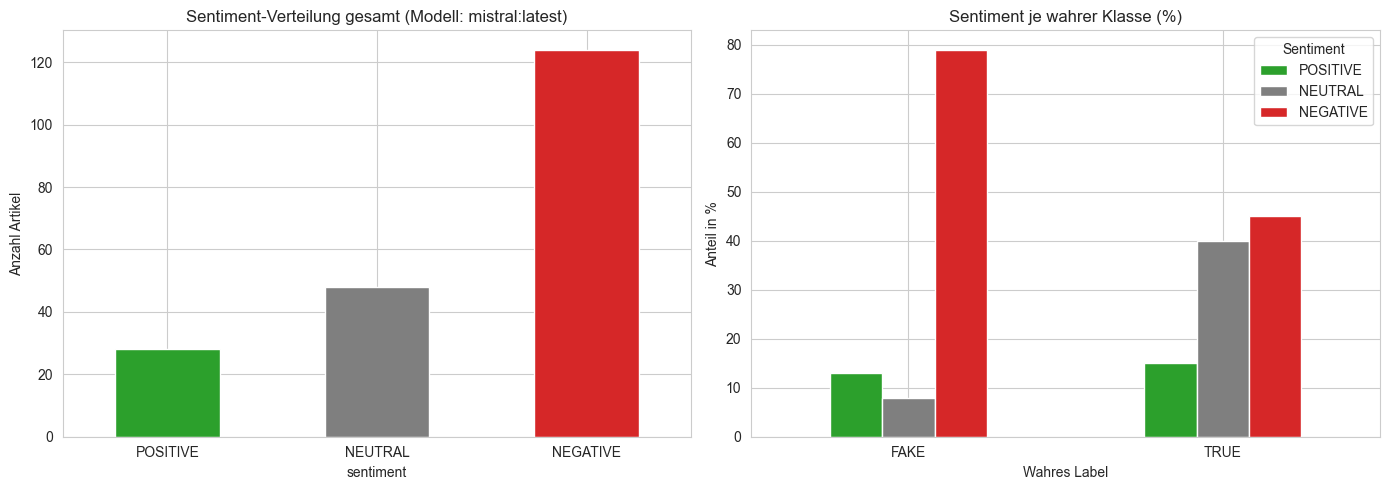

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'POSITIVE': '#2ca02c', 'NEUTRAL': '#7f7f7f', 'NEGATIVE': '#d62728'}

overall.plot.bar(ax=axes[0], color=[palette[s] for s in overall.index])
axes[0].set_title(f'Sentiment-Verteilung gesamt (Modell: {SENTIMENT_MODEL})')
axes[0].set_ylabel('Anzahl Artikel')
axes[0].tick_params(axis='x', rotation=0)

crosstab_pct.plot.bar(ax=axes[1], color=[palette[s] for s in crosstab_pct.columns], stacked=False)
axes[1].set_title('Sentiment je wahrer Klasse (%)')
axes[1].set_ylabel('Anteil in %')
axes[1].set_xlabel('Wahres Label')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentiment')
plt.tight_layout()
plt.show()

### 9.2 Beispiele je Sentiment-Klasse

In [ ]:
examples = valid_sent.merge(sample[['title']], left_on='sample_idx', right_index=True, how='left')
examples = (
    examples.sort_values('confidence', ascending=False)
            .groupby('sentiment')
            .head(2)
            .sort_values(['sentiment', 'confidence'], ascending=[True, False])
)
examples[['sentiment', 'label_true', 'confidence', 'title', 'reason']]